In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy
from statsmodels.graphics.tsaplots import plot_acf, acf
from matplotlib.ticker import PercentFormatter
from scipy.integrate import quad
from math import cos, sqrt
import pandas as pd
import yaml
import os
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/lgssm/data/"

In [2]:
def generate_latent_states(rho, tau, T):
    """
    Generates latent trajectory z_{0:T} for the linear Gaussian SSM:
        z_0   ~ N(0, 1)
        z_k   = rho * z_{k-1} + tau * eps_k,   eps_k ~ N(0, 1)

    Parameters
    ----------
    rho : float, AR coefficient
    tau : float, transition noise std
    T   : int, number of time steps (trajectory length T+1)

    Returns
    -------
    zs  : np.array of shape (T+1,)
    """
    zs = np.zeros(T + 1)
    zs[0] = scipy.stats.norm.rvs(loc=0, scale=1)
    for k in range(1, T + 1):
        zs[k] = scipy.stats.norm.rvs(loc=rho * zs[k-1], scale=tau)
    return zs


def generate_observations(zs, sigma):
    """
    Generates observations x_{0:T} given latent states z_{0:T}:
        x_k | z_k ~ N(z_k, sigma^2)

    Parameters
    ----------
    zs    : np.array of shape (T+1,), latent states
    sigma : float, observation noise std

    Returns
    -------
    xs    : np.array of shape (T+1,)
    """
    return scipy.stats.norm.rvs(loc=zs, scale=sigma)


# True parameters
T         = 5000
rho_true  = 0.8
tau_true  = 1.0
sigma_true = 20

# Generate trajectory
z = generate_latent_states(rho_true, tau_true, T)
x = generate_observations(z, sigma_true)

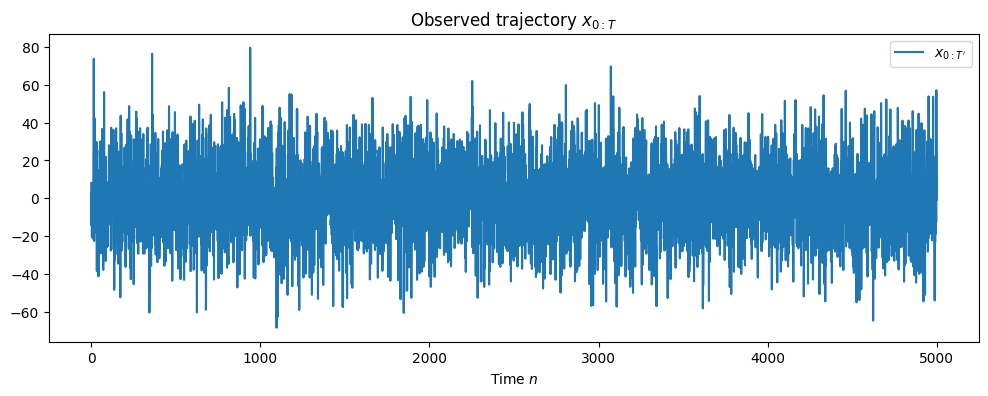

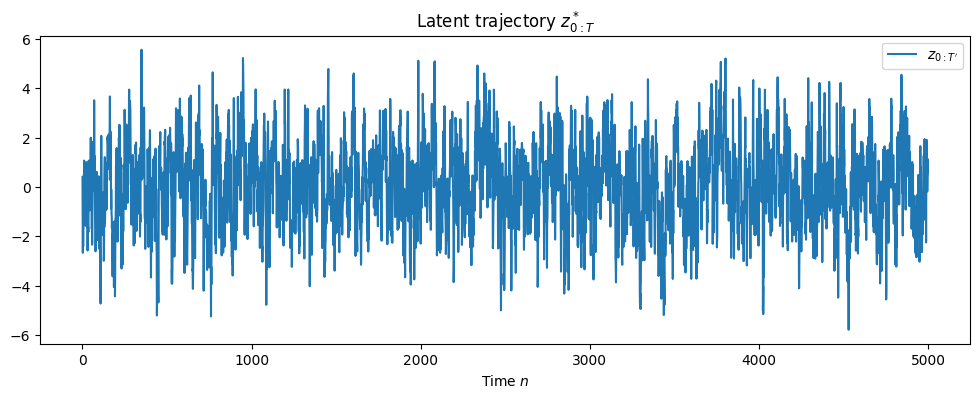

In [3]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(x, label=r"$x_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"Observed trajectory $x_{0:T}$")
plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(z, label=r"$z_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"Latent trajectory $z^*_{0:T}$")
plt.show()

In [4]:
# Find next ID
i = 0
while os.path.exists(results_path + f"/trajectory{i}.yaml"):
    i += 1

In [6]:
config = {"length": T,
          "sigma_true": sigma_true,
          "rho_true": rho_true,
          "tau_true": tau_true}

trajectory = {"z": z,
              "x": x}

In [7]:
trajectory_path = results_path + f"trajectory{i}.npz"
config_path = results_path + f"trajectory{i}.yaml"

np.savez(trajectory_path, **trajectory)

with open(config_path, "w") as f:
    yaml.dump(config, f)